In [2]:
import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from torchvision.datasets import CIFAR10

In [3]:
from torch.utils.data  import DataLoader
import torchvision.transforms as transforms
transform=transforms.Compose([
    transforms.ToTensor()
    ,transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
trainset=CIFAR10(root="./data",train=True,download=True,transform=transform)
testset=CIFAR10(root="./data",train=False,download=True,transform=transform)

In [4]:
trainloader=DataLoader(trainset,batch_size=64,shuffle=True)
testloader=DataLoader(testset,batch_size=64)

# CNN

In [6]:
from model import CNN
model =CNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer =optim.Adam(model.parameters())

In [8]:
epochs = 10
best_acc = 0

for epoch in range(epochs):

    model.train()
    epoch_training_loss = 0.0

    for images, labels in trainloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_training_loss += loss.item()

    print(f"{epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")


    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(testloader)
    val_acc = 100 * correct / total

    print(f"Validation -> loss={avg_val_loss:.4f}, acc={val_acc:.2f}%\n")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    model.train()

1/10 & loss=1.5678636372241828
Validation -> loss=1.2379, acc=55.21%

2/10 & loss=1.24273017071702
Validation -> loss=1.0621, acc=63.06%

3/10 & loss=1.0989705595518926
Validation -> loss=0.9284, acc=68.04%

4/10 & loss=1.005816395630312
Validation -> loss=0.8549, acc=70.55%

5/10 & loss=0.9380111003775731
Validation -> loss=0.8049, acc=71.60%

6/10 & loss=0.8821071980859313
Validation -> loss=0.8041, acc=71.87%

7/10 & loss=0.8534293746399453
Validation -> loss=0.7679, acc=73.35%

8/10 & loss=0.8182079945988667
Validation -> loss=0.7496, acc=74.28%

9/10 & loss=0.7935457103849982
Validation -> loss=0.7175, acc=75.53%

10/10 & loss=0.7712737370634932
Validation -> loss=0.6997, acc=76.29%



In [9]:
# Evaluation
correct_labels=0
total_labels=0
model.eval()
with torch.no_grad():
    for images , labels in testloader:
        outputs=model.forward(images)
        _,predicted=torch.max(outputs,1)
        correct_labels+=(predicted==labels).sum().item()
        total_labels+=labels.size(0)
print(f"Accuracy = {correct_labels/total_labels*100}")

Accuracy = 76.29


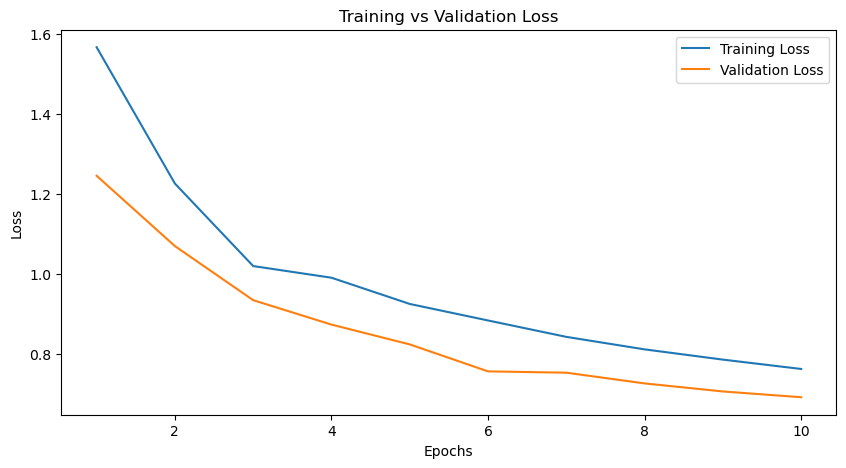

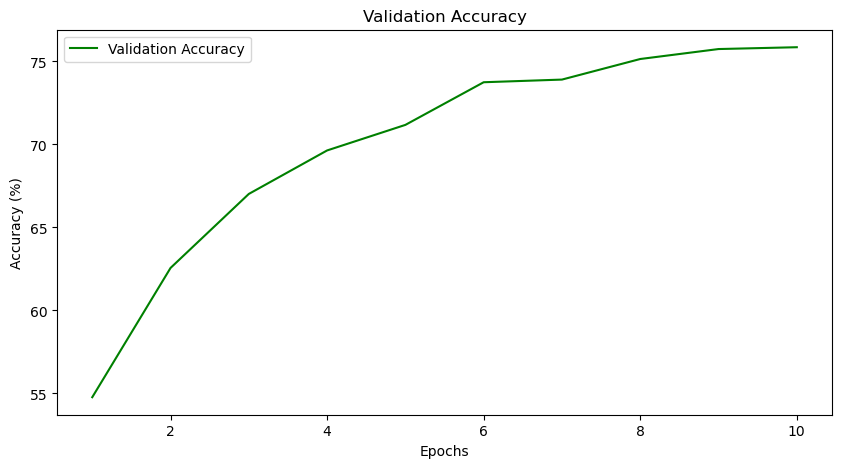

In [1]:
import matplotlib.pyplot as plt

train_losses = [1.5658, 1.22509, 1.01888, 0.98975, 0.92419, 0.88290, 0.84193, 0.81068, 0.7851, 0.7617]
val_losses   = [1.2445, 1.0688, 0.9336, 0.8726, 0.8231, 0.7557, 0.7524, 0.7256, 0.7055, 0.6911]
val_accuracy =[54.77, 62.56, 67.02, 69.64, 71.18, 73.75, 73.91, 75.15, 75.75, 75.86]

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend()
plt.show()